# Hierarchical Clustering: Agglomerative & Divisive Clustering, Dendrograms, Distance Matrices

This notebook walks through hierarchical clustering step by step with runnable code:

1. Building a distance matrix from scratch
2. Agglomerative clustering with `scipy` (single, complete, average, ward linkage)
3. Plotting and interpreting dendrograms
4. Cutting the dendrogram to get flat clusters
5. Agglomerative clustering with `scikit-learn`
6. A simple from-scratch implementation of agglomerative clustering (for intuition)
7. A brief look at divisive clustering
8. Comparing linkage methods visually


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)


## 1. Create a Small Sample Dataset

We'll start with a small, easy-to-visualize 2D dataset so we can trace the algorithm by hand.


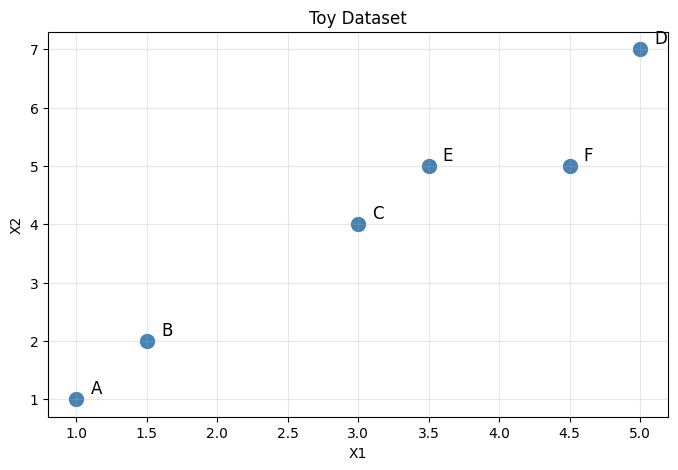

In [2]:
# A small toy dataset of 6 points
X = np.array([
    [1, 1],
    [1.5, 2],
    [3, 4],
    [5, 7],
    [3.5, 5],
    [4.5, 5],
])
labels = ['A', 'B', 'C', 'D', 'E', 'F']

plt.scatter(X[:, 0], X[:, 1], s=100, color='steelblue')
for i, lbl in enumerate(labels):
    plt.annotate(lbl, (X[i, 0] + 0.1, X[i, 1] + 0.1), fontsize=12)
plt.title('Toy Dataset')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(alpha=0.3)
plt.show()


## 2. Building the Distance Matrix

The distance matrix stores the pairwise distance between every pair of points. We'll use **Euclidean distance** here.


In [3]:
dist_condensed = pdist(X, metric='euclidean')   # condensed form (1D)
dist_matrix = squareform(dist_condensed)         # convert to full n x n matrix

dist_df = pd.DataFrame(dist_matrix, index=labels, columns=labels).round(2)
dist_df


,A,B,C,D,E,F
A,0.00,1.12,3.61,7.21,4.72,5.32
B,1.12,0.00,2.50,6.10,3.61,4.24
C,3.61,2.50,0.00,3.61,1.12,1.80
D,7.21,6.10,3.61,0.00,2.50,2.06
E,4.72,3.61,1.12,2.50,0.00,1.00
F,5.32,4.24,1.80,2.06,1.00,0.00


Each cell `(i, j)` shows the Euclidean distance between point `i` and point `j`. The diagonal is always 0 (distance from a point to itself), and the matrix is symmetric.

This is the matrix agglomerative clustering uses at the very first step — it repeatedly finds the smallest off-diagonal value and merges those two clusters.


## 3. Agglomerative Clustering with SciPy

`scipy.cluster.hierarchy.linkage` performs the full agglomerative merge process and returns a **linkage matrix** that encodes the entire merge history — this is exactly what's needed to draw a dendrogram.

We'll try a few different **linkage criteria**:
- `single`   — minimum distance between clusters
- `complete` — maximum distance between clusters
- `average`  — average distance between clusters
- `ward`     — minimizes increase in within-cluster variance


In [4]:
Z_ward = linkage(X, method='ward', metric='euclidean')

# Each row of Z represents one merge: [cluster_idx_1, cluster_idx_2, distance, num_original_points]
linkage_df = pd.DataFrame(Z_ward, columns=['Cluster 1', 'Cluster 2', 'Distance', 'Sample Count'])
linkage_df


,Cluster 1,Cluster 2,Distance,Sample Count
0,4.0,5.0,1.000000,2.0
1,0.0,1.0,1.118034,2.0
2,2.0,6.0,1.632993,3.0
3,3.0,8.0,3.291403,4.0
4,7.0,9.0,7.593857,6.0


Reading this table: points 0-5 are the original 6 points (indices 0..5). Once two clusters are merged, the new cluster gets index `n + merge_number` (here n=6), so index 6 is the first new cluster formed, index 7 is the next, and so on. This is exactly the information plotted in a dendrogram.


## 4. Plotting the Dendrogram


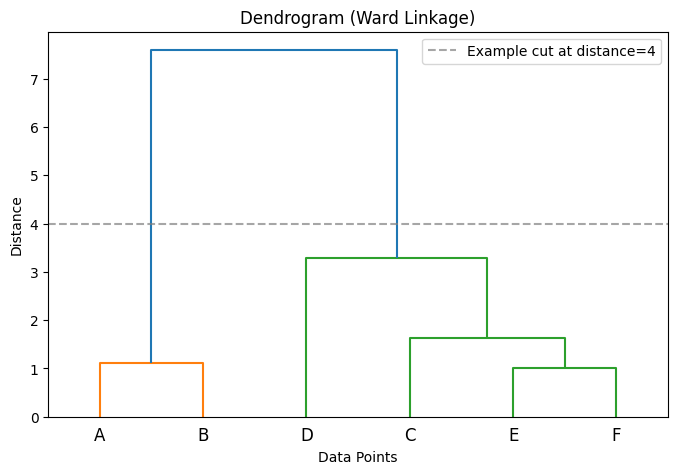

In [5]:
plt.figure(figsize=(8, 5))
dendrogram(Z_ward, labels=labels)
plt.title('Dendrogram (Ward Linkage)')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.axhline(y=4, color='gray', linestyle='--', alpha=0.7, label='Example cut at distance=4')
plt.legend()
plt.show()


**How to read this dendrogram:**
- The leaves at the bottom are the individual points.
- Each "U" shape shows where two clusters merged; the height of the U is the distance at which they merged.
- Drawing a horizontal line (the dashed gray line above) and counting how many vertical lines it crosses tells you how many clusters you'd get by cutting at that distance.


## 5. Comparing Different Linkage Methods

Let's compare `single`, `complete`, `average`, and `ward` linkage side by side on the same data.


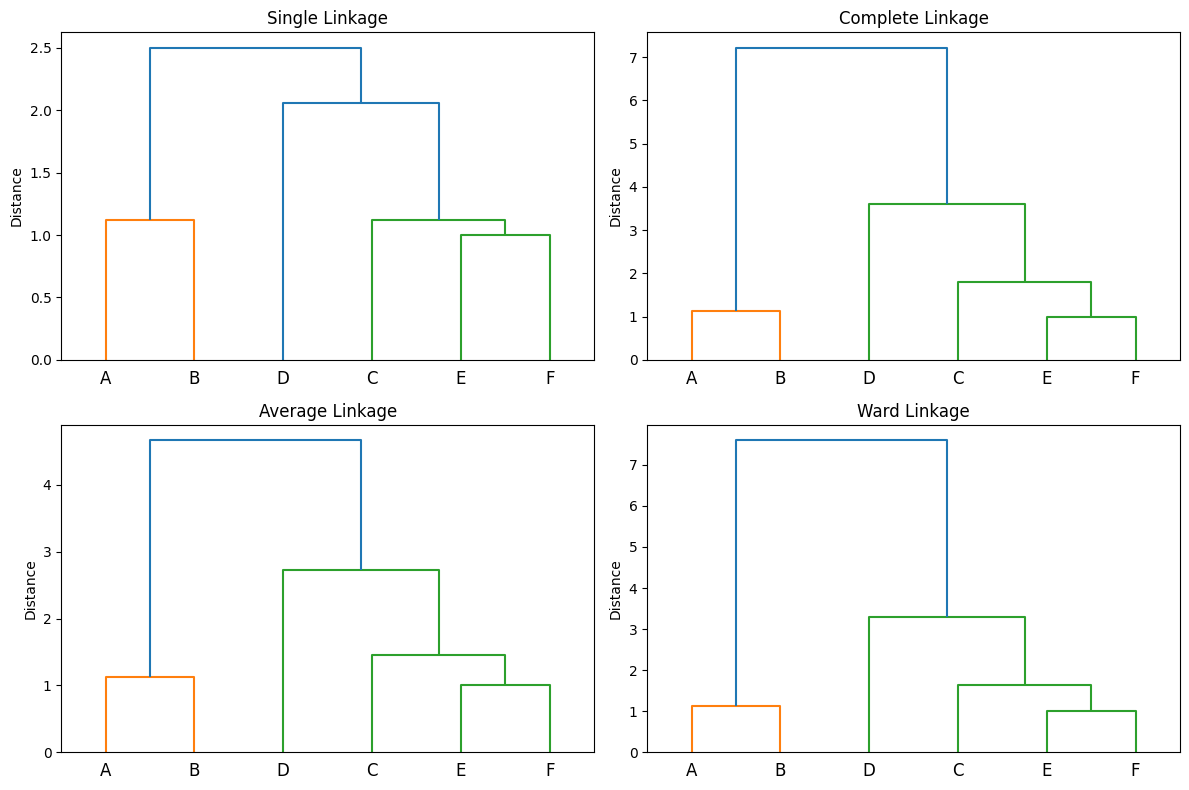

In [6]:
methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, method in zip(axes.ravel(), methods):
    Z = linkage(X, method=method)
    dendrogram(Z, labels=labels, ax=ax)
    ax.set_title(f'{method.capitalize()} Linkage')
    ax.set_ylabel('Distance')

plt.tight_layout()
plt.show()


Notice how the merge heights and even the merge order can differ depending on the linkage method — this is why linkage choice matters and is worth experimenting with on real data.


## 6. Cutting the Dendrogram to Get Flat Clusters

`fcluster` lets us "cut" the dendrogram either by a distance threshold or by a target number of clusters.


In [7]:
# Option A: cut by number of clusters
cluster_labels_k = fcluster(Z_ward, t=2, criterion='maxclust')
print('Cluster assignment (k=2 clusters):', dict(zip(labels, cluster_labels_k)))

# Option B: cut by a distance threshold
cluster_labels_dist = fcluster(Z_ward, t=4, criterion='distance')
print('Cluster assignment (distance threshold=4):', dict(zip(labels, cluster_labels_dist)))


Cluster assignment (k=2 clusters): {'A': np.int32(1), 'B': np.int32(1), 'C': np.int32(2), 'D': np.int32(2), 'E': np.int32(2), 'F': np.int32(2)}
Cluster assignment (distance threshold=4): {'A': np.int32(1), 'B': np.int32(1), 'C': np.int32(2), 'D': np.int32(2), 'E': np.int32(2), 'F': np.int32(2)}


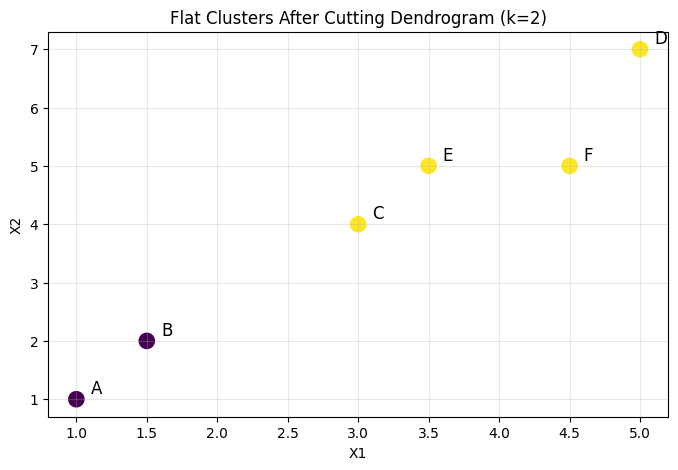

In [8]:
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels_k, cmap='viridis', s=120)
for i, lbl in enumerate(labels):
    plt.annotate(lbl, (X[i, 0] + 0.1, X[i, 1] + 0.1), fontsize=12)
plt.title('Flat Clusters After Cutting Dendrogram (k=2)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(alpha=0.3)
plt.show()


## 7. Agglomerative Clustering with Scikit-learn

`scikit-learn`'s `AgglomerativeClustering` is the go-to interface when you just want cluster labels (rather than the full dendrogram structure) and want to plug clustering into a larger ML pipeline.


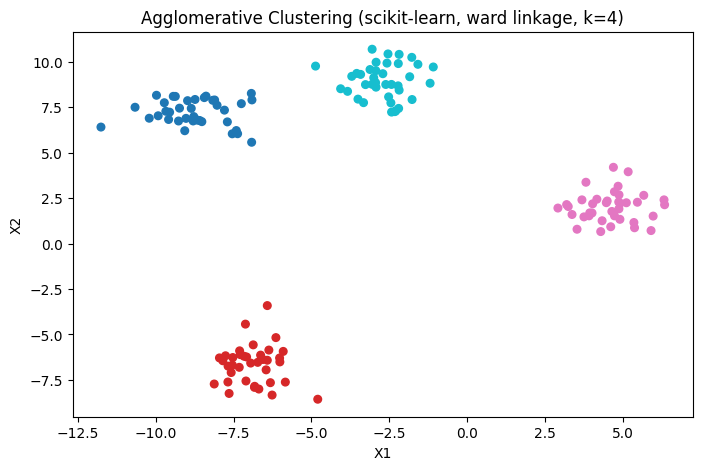

In [9]:
# A larger, more realistic dataset for demonstration
X_big, y_true = make_blobs(n_samples=150, centers=4, cluster_std=0.9, random_state=42)

model = AgglomerativeClustering(n_clusters=4, linkage='ward')
pred_labels = model.fit_predict(X_big)

plt.scatter(X_big[:, 0], X_big[:, 1], c=pred_labels, cmap='tab10', s=30)
plt.title('Agglomerative Clustering (scikit-learn, ward linkage, k=4)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()


## 8. A Minimal From-Scratch Implementation

To build intuition, here's a simple (unoptimized) implementation of agglomerative clustering with **single linkage**, written from scratch using only NumPy. This mirrors the algorithm described in `theory.md`:

1. Start with every point as its own cluster.
2. Repeatedly merge the two closest clusters.
3. Stop when the target number of clusters is reached.


In [10]:
def agglomerative_single_linkage(X, n_clusters=1):
    n = X.shape[0]
    # Each cluster starts as a list containing the indices of its points
    clusters = {i: [i] for i in range(n)}
    dist = squareform(pdist(X, metric='euclidean'))

    def cluster_distance(c1, c2):
        # Single linkage: distance between the two closest points, one from each cluster
        return min(dist[i, j] for i in clusters[c1] for j in clusters[c2])

    history = []
    active_ids = list(clusters.keys())
    next_id = n

    while len(active_ids) > n_clusters:
        # Find the closest pair of active clusters
        best_pair, best_dist = None, np.inf
        for a_idx in range(len(active_ids)):
            for b_idx in range(a_idx + 1, len(active_ids)):
                c1, c2 = active_ids[a_idx], active_ids[b_idx]
                d = cluster_distance(c1, c2)
                if d < best_dist:
                    best_dist, best_pair = d, (c1, c2)

        c1, c2 = best_pair
        merged_points = clusters[c1] + clusters[c2]
        clusters[next_id] = merged_points
        history.append((c1, c2, best_dist, len(merged_points)))

        active_ids.remove(c1)
        active_ids.remove(c2)
        active_ids.append(next_id)
        next_id += 1

    final_clusters = {cid: clusters[cid] for cid in active_ids}
    return final_clusters, history

final_clusters, merge_history = agglomerative_single_linkage(X, n_clusters=2)

print('Merge history (cluster_1, cluster_2, distance, size):')
for step in merge_history:
    print(' ', step)

print('\nFinal clusters:')
for cid, points in final_clusters.items():
    print(f'  Cluster {cid}: {[labels[p] for p in points]}')


Merge history (cluster_1, cluster_2, distance, size):
  (4, 5, np.float64(1.0), 2)
  (0, 1, np.float64(1.118033988749895), 2)
  (2, 6, np.float64(1.118033988749895), 3)
  (3, 8, np.float64(2.0615528128088303), 4)

Final clusters:
  Cluster 7: ['A', 'B']
  Cluster 9: ['D', 'C', 'E', 'F']


Compare the merge order and distances above to the SciPy `linkage` output in Section 3 — with `method='single'` they should match (small floating point differences aside).


## 9. Divisive Clustering (Top-Down) — A Simple Illustration

`scipy`/`sklearn` don't ship a dedicated divisive clustering function (it's far less common in practice), but we can illustrate the idea with a simple **recursive bisecting k-means** approach: repeatedly split the largest/most spread-out cluster into two using k-means (k=2), until we reach the desired number of clusters.


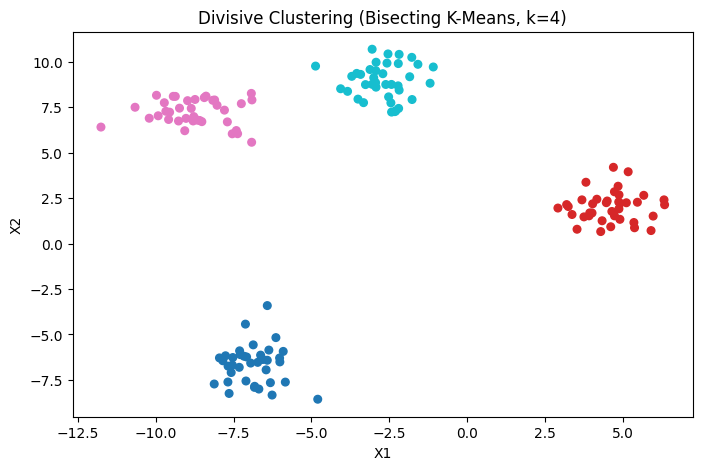

In [11]:
from sklearn.cluster import KMeans

def bisecting_kmeans(X, n_clusters=4, random_state=42):
    # Start with a single cluster containing all points
    clusters = [np.arange(X.shape[0])]

    while len(clusters) < n_clusters:
        # Pick the largest cluster to split (a common divisive heuristic)
        sizes = [len(c) for c in clusters]
        idx_to_split = int(np.argmax(sizes))
        cluster_to_split = clusters.pop(idx_to_split)

        km = KMeans(n_clusters=2, n_init=10, random_state=random_state)
        sub_labels = km.fit_predict(X[cluster_to_split])

        clusters.append(cluster_to_split[sub_labels == 0])
        clusters.append(cluster_to_split[sub_labels == 1])

    # Convert to a flat label array
    flat_labels = np.empty(X.shape[0], dtype=int)
    for cid, idxs in enumerate(clusters):
        flat_labels[idxs] = cid
    return flat_labels

divisive_labels = bisecting_kmeans(X_big, n_clusters=4)

plt.scatter(X_big[:, 0], X_big[:, 1], c=divisive_labels, cmap='tab10', s=30)
plt.title('Divisive Clustering (Bisecting K-Means, k=4)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()


## 10. Summary

| Concept | Where to see it above |
|---|---|
| Distance matrix | Section 2 |
| Agglomerative (bottom-up) clustering | Sections 3, 7, 8 |
| Dendrogram | Sections 3, 4, 5 |
| Linkage methods (single/complete/average/ward) | Section 5 |
| Cutting a dendrogram into flat clusters | Section 6 |
| Divisive (top-down) clustering | Section 9 |

For the conceptual explanations behind each of these (why Ward's method tends to produce balanced clusters, how to interpret dendrogram heights, when to prefer agglomerative over divisive, etc.), see the accompanying `theory.md`.
